<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (0.5 балла)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [2]:
from PIL import Image
from torchvision.datasets import DatasetFolder


def get_dataloader(image_size, batch_size, root_dir = 'dataset'):
  """
  Builds dataloader for training data.
  Use tt.Compose and tt.Resize for transformations
  :param image_size: height and wdith of the image
  :param batch_size: batch_size of the dataloader
  :returns: DataLoader object
  """
  # TODO: resize images, convert them to tensors and build dataloader
  transform = tt.Compose([
      tt.Resize((image_size, image_size)),
      tt.ToTensor()
  ])
  dataset = DatasetFolder(
    root=root_dir,
    loader=lambda path: Image.open(path).convert("RGB"),
    extensions=("png",),
    transform=transform,
  )
  loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
  )
  return loader

In [3]:
image_size = 128

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

dataloader = get_dataloader(image_size, batch_size=32)
#TODO: build dataloader and transfer it to device

## Часть 2. Построение и обучение модели (2 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [4]:
discriminator = nn.Sequential(
    # in: 3 × 128 × 128
    nn.Conv2d(  3,  64, 4, 2, 1, bias=False),  # → 64 × 64 × 64
    nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d( 64, 128, 4, 2, 1, bias=False),  # → 128 × 32 × 32
    nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(128, 256, 4, 2, 1, bias=False),  # → 256 × 16 × 16
    nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(256, 512, 4, 2, 1, bias=False),  # → 512  × 8 ×  8
    nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),

    # ← вот этот блок мы добавляем:
    nn.Conv2d(512, 512, 4, 2, 1, bias=False),  # → 512  × 4 ×  4
    nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),

    # финальная свёртка 4×4 → 1×1
    nn.Conv2d(512,   1, 4, 1, 0, bias=False),  # → 1    × 1 ×  1
    nn.Flatten(),
    nn.Sigmoid()
)

In [5]:
latent_size = 64

generator = nn.Sequential(
    # in: latent_size × 1 × 1
    nn.ConvTranspose2d(latent_size, 512, 4, 1, 0, bias=False),  # → 512 × 4 × 4
    nn.BatchNorm2d(512), nn.ReLU(True),

    nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),         # → 256 × 8 × 8
    nn.BatchNorm2d(256), nn.ReLU(True),

    nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),         # → 128 ×16 ×16
    nn.BatchNorm2d(128), nn.ReLU(True),

    nn.ConvTranspose2d(128,  64, 4, 2, 1, bias=False),         # →  64 ×32 ×32
    nn.BatchNorm2d(64),  nn.ReLU(True),

    nn.ConvTranspose2d( 64,  32, 4, 2, 1, bias=False),         # →  32 ×64 ×64
    nn.BatchNorm2d(32),  nn.ReLU(True),

    # ← дополнительный слой для 128×128:
    nn.ConvTranspose2d( 32,   3, 4, 2, 1, bias=False),         # →   3 ×128×128
    nn.Tanh()
)

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [6]:
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}
model["discriminator"] = model["discriminator"].to(device)
model["generator"]     = model["generator"].to(device)

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

In [7]:
def fit(model, criterion, epochs, lr):
    model["discriminator"].train()
    model["generator"].train()
    torch.cuda.empty_cache()

    # Losses & scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []

    # Create optimizers
    optimizer = {
        "discriminator": torch.optim.Adam(model["discriminator"].parameters(),
                                          lr=lr, betas=(0.5, 0.999)),
        "generator": torch.optim.Adam(model["generator"].parameters(),
                                      lr=lr, betas=(0.5, 0.999))
    }
    batch_size = dataloader.batch_size
    for epoch in range(epochs):
        loss_d_per_epoch = []
        loss_g_per_epoch = []
        real_score_per_epoch = []
        fake_score_per_epoch = []
        for real_images, _ in tqdm(dataloader):
            real_images = real_images.to(device, non_blocking=True)
            # Train discriminator
            # Clear discriminator gradients
            optimizer["discriminator"].zero_grad()

            # Pass real images through discriminator
            real_preds = model["discriminator"](real_images)
            real_targets = torch.ones(real_images.size(0), 1, device=device)
            real_loss = criterion["discriminator"](real_preds, real_targets)
            cur_real_score = torch.mean(real_preds).item()

            # Generate fake images
            latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)

            # Pass fake images through discriminator
            fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
            fake_preds = model["discriminator"](fake_images)
            fake_loss = criterion["discriminator"](fake_preds, fake_targets)
            cur_fake_score = torch.mean(fake_preds).item()

            real_score_per_epoch.append(cur_real_score)
            fake_score_per_epoch.append(cur_fake_score)

            # Update discriminator weights
            loss_d = real_loss + fake_loss
            loss_d.backward()
            optimizer["discriminator"].step()
            loss_d_per_epoch.append(loss_d.item())


            # Train generator
            # Clear generator gradients
            optimizer["generator"].zero_grad()

            # Generate fake images
            latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = model["generator"](latent)

            # Try to fool the discriminator
            preds = model["discriminator"](fake_images)
            targets = torch.ones(batch_size, 1, device=device)
            loss_g = criterion["generator"](preds, targets)

            # Update generator weights
            loss_g.backward()
            optimizer["generator"].step()
            loss_g_per_epoch.append(loss_g.item())

        # Record losses & scores
        losses_g.append(np.mean(loss_g_per_epoch))
        losses_d.append(np.mean(loss_d_per_epoch))
        real_scores.append(np.mean(real_score_per_epoch))
        fake_scores.append(np.mean(fake_score_per_epoch))

        # Log losses & scores (last batch)
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs,
            losses_g[-1], losses_d[-1], real_scores[-1], fake_scores[-1]))


    return losses_g, losses_d, real_scores, fake_scores

In [8]:
epochs = 50
history = fit(model, criterion, epochs, lr)

  0%|          | 0/99 [00:00<?, ?it/s]

Epoch [1/50], loss_g: 9.2239, loss_d: 0.0417, real_score: 0.9862, fake_score: 0.0205


  0%|          | 0/99 [00:00<?, ?it/s]

Epoch [2/50], loss_g: 13.4161, loss_d: 0.0491, real_score: 0.9909, fake_score: 0.0047


  0%|          | 0/99 [00:00<?, ?it/s]

...

Epoch [48/50], loss_g: 7.6465, loss_d: 0.1549, real_score: 0.9468, fake_score: 0.0534


  0%|          | 0/99 [00:00<?, ?it/s]

Epoch [49/50], loss_g: 7.2730, loss_d: 0.2491, real_score: 0.9330, fake_score: 0.0611


  0%|          | 0/99 [00:00<?, ?it/s]

Epoch [50/50], loss_g: 6.5554, loss_d: 0.2086, real_score: 0.9313, fake_score: 0.0736


Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

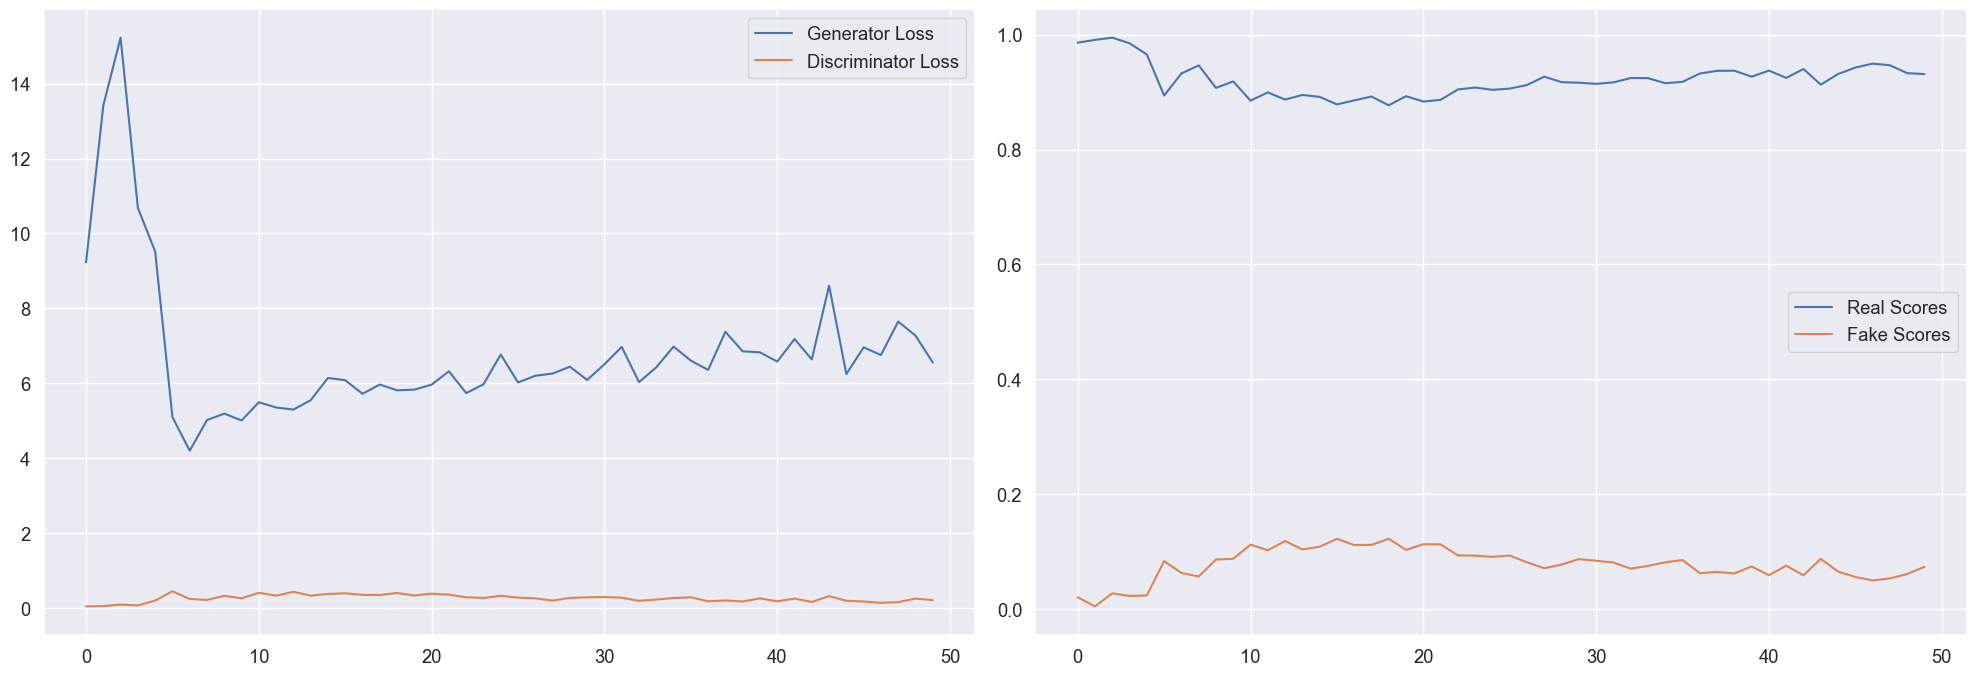

In [17]:
#losses_g, losses_d, real_scores, fake_scores

fig, axes = plt.subplots(1,2, figsize=(20,7))
axes[0].plot(history[0], label="Generator Loss")
axes[0].plot(history[1], label="Discriminator Loss")
axes[0].legend()
axes[1].plot(history[2], label="Real Scores")
axes[1].plot(history[3], label="Fake Scores")
axes[1].legend()
plt.tight_layout()
plt.show()

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [26]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)

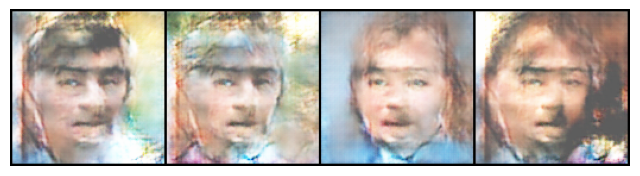

In [27]:
grid = make_grid(fake_images.cpu().detach(),
                 nrow=n_images,
                 normalize=True)         # диапазон ваших данных

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1, 2, 0))  # (H, W, C)
plt.axis('off')
plt.show()

Как вам качество получившихся изображений?

## Часть 4. Leave-one-out-1-NN classifier accuracy (6 баллов)

### 4.1. Подсчет accuracy (1.5 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [34]:
import torch
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut

def compute_gan_loo_accuracy(generator,
                             dataloader,
                             latent_size,
                             device,
                             batch_size=32):
    real_imgs = []
    for imgs, _ in dataloader:
        real_imgs.append(imgs)
    real_imgs = torch.cat(real_imgs, dim=0)                  # shape (N, C, H, W)
    N = real_imgs.size(0)

    fake_imgs = []
    generator.eval()
    with torch.no_grad():
        for i in range(0, N, batch_size):
            this_bs = min(batch_size, N - i)
            z = torch.randn(this_bs, latent_size, 1, 1, device=device)
            fake = generator(z).cpu()                         # to CPU
            fake_imgs.append(fake)
    fake_imgs = torch.cat(fake_imgs, dim=0)                  # shape (N, C, H, W)
    generator.train()

    X_real = real_imgs.view(N, -1).cpu().numpy()             # (N, C*H*W)
    X_fake = fake_imgs.view(N, -1).numpy()                   # (N, C*H*W)

    X = np.vstack([X_real, X_fake])                          # (2N, D)
    y = np.concatenate([np.ones(N), np.zeros(N)])            # (2N,)

    loo = LeaveOneOut()
    clf = KNeighborsClassifier(n_neighbors=1)
    correct = 0
    for train_idx, test_idx in loo.split(X):
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[test_idx])
        if pred == y[test_idx]:
            correct += 1

    accuracy = correct / len(y)
    print(f"1-NN LOO accuracy: {accuracy:.4f}")
    return accuracy

accuracy = compute_gan_loo_accuracy(
    generator=model["generator"],
    dataloader=dataloader,
    latent_size=latent_size,
    device=device,
    batch_size=32
)


1-NN LOO accuracy: 0.9825


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

### Ответ
Хотели бы что то близкое к 1/2, означающее что фейковые и реальные фотки очень похожи. а пока что генератор такой себе

### 4.2. Визуализация распределений (1 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

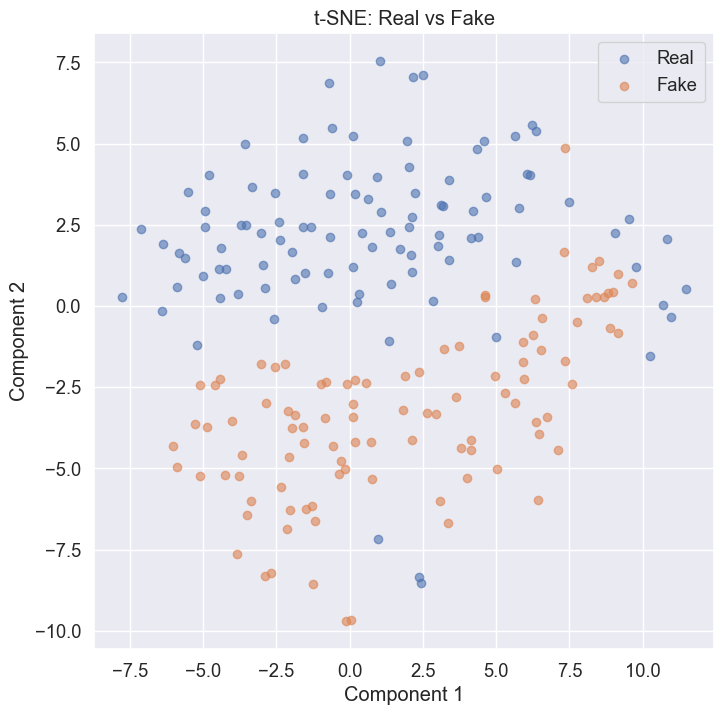

In [35]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Возьмём по 100 примеров каждого типа
sample_size = 100

# 1) Собираем реальные изображения
real_imgs = []
for imgs, _ in dataloader:
    real_imgs.append(imgs)
    if sum(x.size(0) for x in real_imgs) >= sample_size:
        break
real_imgs = torch.cat(real_imgs, 0)[:sample_size]          # (100, C, H, W)
real_feats = real_imgs.view(sample_size, -1).cpu().numpy()  # (100, D)

# 2) Генерируем fake изображения
generator.eval()
with torch.no_grad():
    z = torch.randn(sample_size, latent_size, 1, 1, device=device)
    fake_imgs = generator(z).cpu()
fake_feats = fake_imgs.view(sample_size, -1).numpy()       # (100, D)
generator.train()

# 3) Собираем X и метки y
X = np.vstack([real_feats, fake_feats])                    # (200, D)
y = np.array([1]*sample_size + [0]*sample_size)            # 1=real, 0=fake

# 4) Запускаем t-SNE
tsne = TSNE(n_components=2, init='pca', random_state=42)
X2 = tsne.fit_transform(X)                                 # (200, 2)

# 5) Рисуем
plt.figure(figsize=(8,8))
plt.scatter(X2[y==1,0], X2[y==1,1], label='Real', alpha=0.6)
plt.scatter(X2[y==0,0], X2[y==0,1], label='Fake', alpha=0.6)
plt.legend()
plt.title('t-SNE: Real vs Fake')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()


Прокомментируйте получившийся результат:

генератор далек от идеала, ибо присутствует четкое разделение